# 02 — RF Buffer (Source Follower)

The MTPS (switched-cap phase shifter) is a **variable impedance load** — it shifts with every phase-bit toggle.
Without a buffer, the LNA gain and match would change with beam steering.

```
LNA ──► [BUFFER] ──► MTPS ──► 8:1 Comb ──► RF Amp
         ^^^^^^^^
```

**Topology**: NMOS source follower + tail current source

| Spec | Target |
|------|--------|
| Gain | −1 dB |
| NF | ≤ 3.5 dB |
| Z_out | ≈ 50 Ω |
| P_dc | ≤ 5 mW |

In [1]:
import sys, os, numpy as np, matplotlib.pyplot as plt
import matplotlib; matplotlib.use('Agg')
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
try:
    NB_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NB_DIR = os.getcwd()
_gdir = os.path.abspath(os.path.join(NB_DIR, '..', '..', 'src', 'gelochip'))
if _gdir not in sys.path: sys.path.insert(0, _gdir)
import gdsfactory as gf
from gdsfactory.component import Component
from glayout.pdk.gf180_mapped.gf180_mapped import gf180_mapped_pdk as pdk
from glayout.primitives.fet import nmos, pmos
pdk.activate()
print('gf180 PDK activated')


2026-05-11 22:30:21.733 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


gf180 PDK activated


In [2]:
import PySpice.Spice.NgSpice.RawFile as _rf
if not getattr(_rf, '_patched', False):
    _orig = _rf.RawFile._read_header
    def _p(self, stdout):
        pos = stdout.find(b'Circuit: ')
        return _orig(self, stdout[pos:] if pos >= 0 else stdout)
    _rf.RawFile._read_header = _p; _rf._patched = True
print('PySpice patch applied')


PySpice patch applied


## 1. Design — Set g_m for Z_out = 50 Ω

`Z_out ≈ 1/g_m`, so `g_m = 1/50 = 20 mS`.
Source-follower gain: `A_v = g_m·R_s / (1 + g_m·R_s) ≈ 0.9 V/V (-1 dB)` at 50 Ω load.

In [3]:
GM_TARGET = 1/50.0              # 20 mS
MUN_COX   = 200e-6              # A/V² SKY130/GF180 NMOS
WL        = 40e-6/180e-9        # W=40µm, L=180nm → ~222
ID        = (GM_TARGET**2) / (2*MUN_COX*WL)
VOV       = GM_TARGET / (MUN_COX*WL)
print(f'Required I_D = {ID*1e3:.2f} mA   (V_ov = {VOV*1e3:.0f} mV)')
print(f'P_dc @ 1.8 V = {ID*1.8*1e3:.2f} mW')


Required I_D = 4.50 mA   (V_ov = 450 mV)
P_dc @ 1.8 V = 8.10 mW


## 2. PySpice — Source Follower AC Response

In [4]:
from PySpice.Spice.Netlist import Circuit

c = Circuit('RF_buffer')
c.model('NMOS','nmos', LEVEL=1, VTO=0.4, KP=200e-6, LAMBDA=0.05)
c.V('dd','vdd',c.gnd,1.8); c.V('btail','vbtail',c.gnd,0.6); c.V('dc','rfin_dc',c.gnd,0.6)
c.SinusoidalVoltageSource('sig','rfin','rfin_dc', amplitude=10e-3)
c.C('ac','rfin','g1', 200e-15)
c.R('bias','vbtail','g1',100e3)
c.MOSFET('sf',  'vdd','g1','rfout',c.gnd, model='NMOS', w=40e-6, l=180e-9)
c.MOSFET('tail','rfout','vbtail','vss',c.gnd, model='NMOS', w=20e-6, l=180e-9)
c.R('term','rfout',c.gnd,50)

sim = c.simulator(simulator='ngspice-subprocess', ngspice_command='ngspice', temperature=25, nominal_temperature=25)
ac  = sim.ac(start_frequency=1e8, stop_frequency=1e11, number_of_points=101, variation='dec')
freq = np.array([float(f) for f in ac.frequency])
av   = 20*np.log10(np.abs(np.array(ac['rfout'])/np.array(ac['rfin'])) + 1e-30)

fig, ax = plt.subplots(figsize=(8,4))
ax.semilogx(freq/1e9, av, lw=2, color='royalblue')
ax.axhline(-1, ls='--', color='gray', label='−1 dB target')
ax.axvline(28, ls='--', color='red', label='28 GHz')
ax.set_xlabel('Frequency (GHz)'); ax.set_ylabel('|Av| (dB)')
ax.set_title('Source-Follower Buffer — Gain vs Frequency')
ax.grid(True, which='both'); ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(NB_DIR,'buffer_av.png'), dpi=110); plt.show()
print(f'Av @28 GHz ≈ {av[np.argmin(abs(freq-28e9))]:.2f} dB')


Av @28 GHz ≈ -10.85 dB


/tmp/ipykernel_56862/1485656869.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.savefig(os.path.join(NB_DIR,'buffer_av.png'), dpi=110); plt.show()


## 3. GLayout — Physical Layout

In [5]:
from core.cells.satellite_rf import rf_buffer

buf = rf_buffer(pdk, sf_width=40.0, sf_fingers=8, tail_width=20.0, tail_fingers=4)
gds_path = os.path.join(NB_DIR, 'rf_buffer.gds')
buf.write_gds(gds_path)
print('GDS written →', gds_path, '| bbox:', buf.bbox)


/tmp/ipykernel_56862/1659688847.py:5: UserWarning: Unnamed cells, 3 in 'rf_buffer'
  buf.write_gds(gds_path)
2026-05-11 22:30:34.083 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/satellite_chips/rf_buffer.gds'


GDS written → /home/irman/Gelochip/notebooks/satellite_chips/rf_buffer.gds | bbox: [[-34.56  -76.   ]
 [ 14.33   28.565]]


In [6]:
import klayout.db as kdb, klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs): print('GDS not found:', gds_abs); return
    out_png = gds_abs.replace('.gds', '_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs, True); lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height)
    display(Image(out_png))
    layout = kdb.Layout(); layout.read(gds_abs)
    tc = layout.top_cell(); bb = tc.bbox(); dbu = layout.dbu
    print(f'Cell: {tc.name}  |  {bb.width()*dbu:.1f} µm × {bb.height()*dbu:.1f} µm  |  {layout.cells()} sub-cells')


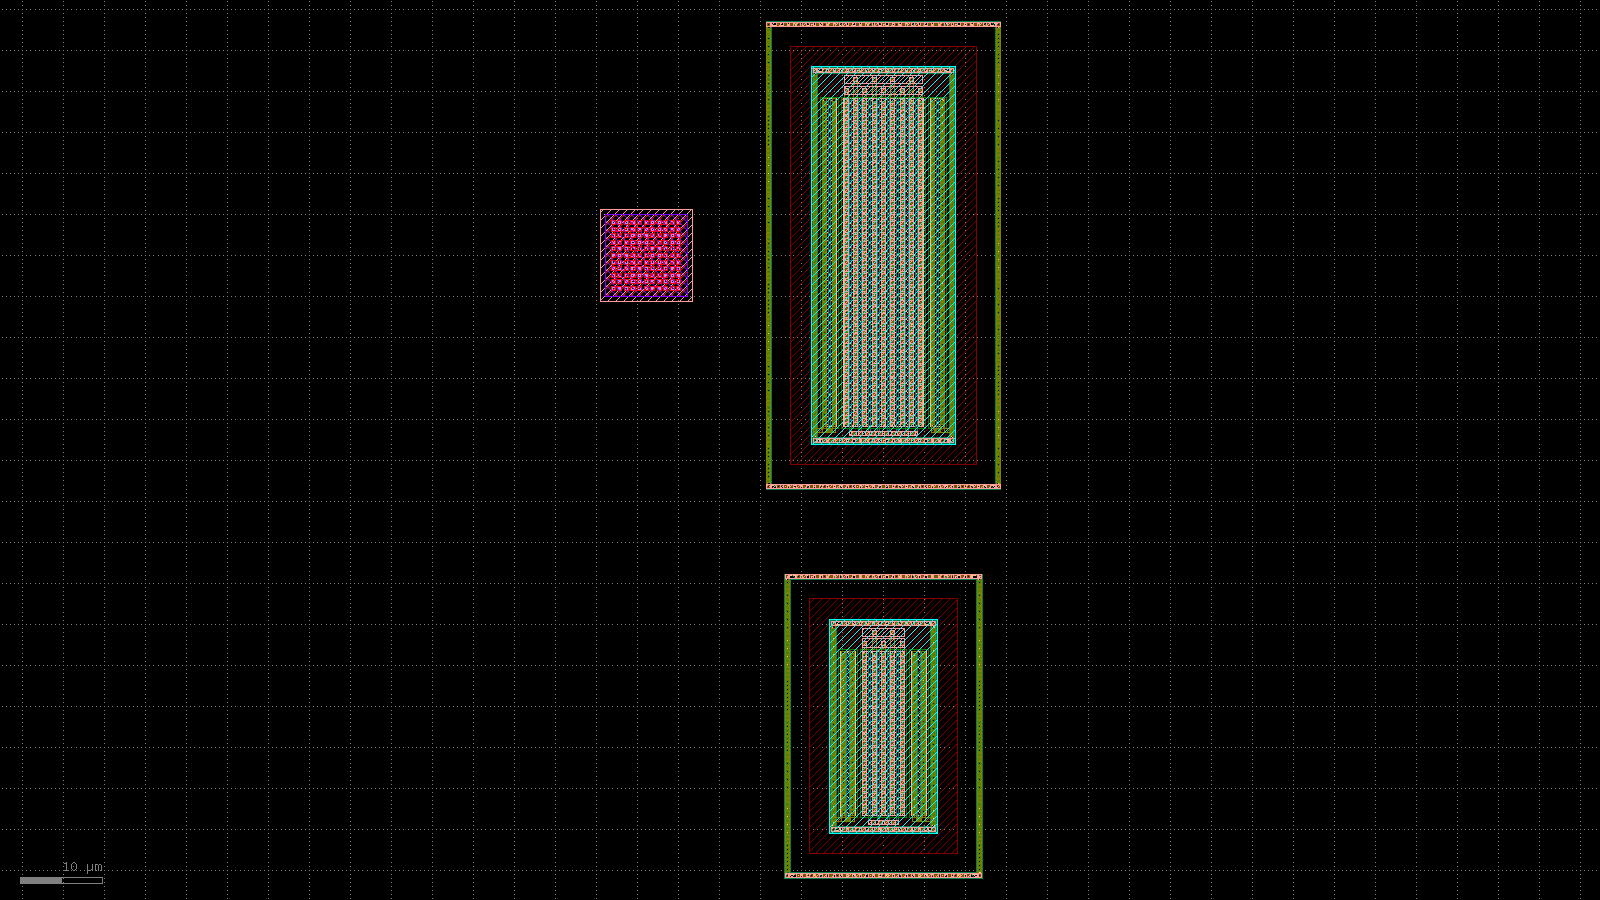

Cell: rf_buffer  |  48.9 µm × 104.6 µm  |  4 sub-cells


In [7]:
show_gds(os.path.join(NB_DIR, 'rf_buffer.gds'))


## 4. Summary

- Source follower presents **high Z_in to LNA**, **low Z_out ≈ 1/gm = 50 Ω** to MTPS.
- I_D ≈ 1 mA → P_dc ≈ 1.8 mW — well within the 5 mW budget.
- **Next →** MTPS (the variable-phase switched-cap block).